##In this notebook, we simulate rainfall-runoff accross CAMELS-FR catchments using GR4J and GRHyMoLAP models.

# IMPORT LIBRARIES

In [ ]:
!pip install git+https://github.com/kratzert/RRMPG.git

  Cloning https://github.com/kratzert/RRMPG.git to /tmp/pip-req-build-opzai35e
  Running command git clone --filter=blob:none --quiet https://github.com/kratzert/RRMPG.git /tmp/pip-req-build-opzai35e
  Resolved https://github.com/kratzert/RRMPG.git to commit 7de78c25acc1c255d2acaf739d65e9ce7bbd60c3
  Preparing metadata (setup.py) ... done


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas import read_csv
import math
import random
from datetime import datetime, timedelta
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

from rrmpg.models import GR4J
import zipfile
import os
from scipy.optimize import minimize
from google.colab import files

In [ ]:
from google.colab import drive

# Monter Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##CAMELS-DATA from my Python library.

In [ ]:
pip install aqua-fetch

In [ ]:
from aqua_fetch import RainfallRunoff

#
rr = RainfallRunoff("CAMELS_FR")

/usr/local/lib/python3.12/dist-packages/aqua_fetch/rr/utils.py:127: UserWarning: netCDF4 module is not installed. Please install it to save data in netcdf format
  warnings.warn(msg, UserWarning)



        Not downloading the data since the directory 
        /usr/local/lib/python3.12/dist-packages/aqua_fetch/data/CAMELS/CAMELS_FR already exists.
        Use overwrite=True to remove previously saved files and download again
P392252001  not found in site_general_attributes.csv
P613402001  not found in site_general_attributes.csv


In [ ]:
meta, ds = rr.fetch()

Read 654 stations for 22 dyn features in 63.98 seconds with 2 cpus.


In [ ]:
import xarray as xr

print(ds)              # aperçu global
#print(ds.coords)       # coordonnées (temps, variables, stations)
#print(ds['912101A'].head())  # exemple : station 5

<xarray.Dataset> Size: 2GB
Dimensions:           (time: 18993, dynamic_features: 22)
Coordinates:
  * time              (time) datetime64[ns] 152kB 1970-01-01 ... 2021-12-31
  * dynamic_features  (dynamic_features) object 176B 'q_cms_obs' ... 'airtemp...
Data variables: (12/654)
    A105003001        (time, dynamic_features) float64 3MB 1.65e+03 ... 13.4
    A107020001        (time, dynamic_features) float64 3MB nan nan ... 4.1 13.3
    A112020001        (time, dynamic_features) float64 3MB 1.04e+03 ... 13.4
    A116003002        (time, dynamic_features) float64 3MB nan nan ... 4.3 13.3
    A140202001        (time, dynamic_features) float64 3MB nan nan ... 6.8 12.4
    A202030001        (time, dynamic_features) float64 3MB nan nan ... 7.1 13.2
    ...                ...
    Y661401001        (time, dynamic_features) float64 3MB 860.0 0.441 ... 14.3
    Y781000101        (time, dynamic_features) float64 3MB nan nan ... 6.4 15.8
    Y862000101        (time, dynamic_features) float64 3MB 

In [ ]:
print(ds.dynamic_features.values)

['q_cms_obs' 'q_mm_obs' 'tsd_val_s' 'tsd_val_q' 'tsd_val_m' 'tsd_val_c'
 'tsd_val_i' 'pcp_mm' 'pcp_mm_solfrac' 'airtemp_C_mean' 'pet_mm_ou'
 'pet_mm_pe' 'pet_mm_pm' 'windspeed_mps' 'spechum_gkg' 'lwdownrad_wm2'
 'solrad_wm2' 'tsd_swi_gr' 'tsd_swi_isba' 'tsd_swe_isba' 'airtemp_C_min'
 'airtemp_C_max']


In [ ]:
# Full period
print(ds["time"].values[0], ds["time"].values[-1])

1970-01-01T00:00:00.000000000 2021-12-31T00:00:00.000000000


#Period used

In [ ]:
ds_recent = ds.sel(time=slice("2000-01-01", "2021-12-31"))

# List of all stations
all_stations = list(ds_recent.keys())

# Selection of features of interest
features = ["q_mm_obs", "pcp_mm", "pet_mm_pm"]

# Count stations without NaN
valid_stations = []

for station_id in all_stations:
    subset = ds_recent[station_id].sel(dynamic_features=features)
    df = subset.to_dataframe().reset_index().pivot(
        index="time", columns="dynamic_features", values=station_id
    )

    if df[features].isna().sum().max() == 0:  # no missing values
        valid_stations.append(station_id)

GR4J

In [ ]:
from numba import njit
import numpy as np
from scipy.optimize import minimize

# ============================================
# General infos
# ============================================
b1_ratio = 0.6
max_missing_ratio = 0.05

stations = all_stations
results_GR4J = {}

# ============================================
# Metric functions (NaNs ignored)
# ============================================
@njit
def NSE(obs, sim):
    n = len(obs)
    mean_obs = 0.0
    count = 0
    for i in range(n):
        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            mean_obs += obs[i]
            count += 1
    if count == 0:
        return np.nan
    mean_obs /= count

    num = 0.0
    den = 0.0
    for i in range(n):
        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            num += (sim[i] - obs[i]) ** 2
            den += (obs[i] - mean_obs) ** 2
    if den == 0:
        return np.nan
    return 1 - num / den


@njit
def RMSE(obs, sim):
    n = len(obs)
    mse = 0.0
    count = 0
    for i in range(n):
        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            diff = sim[i] - obs[i]
            mse += diff * diff
            count += 1
    if count == 0:
        return np.nan
    return np.sqrt(mse / count)


@njit
def runoff_ratio(Q, P):
    n = len(Q)
    sum_Q = 0.0
    sum_P = 0.0
    for i in range(n):
        if not np.isnan(Q[i]) and not np.isnan(P[i]):
            sum_Q += Q[i]
            sum_P += P[i]
    if sum_P == 0:
        return np.nan
    return sum_Q / sum_P


# ============================================
# GR4J objective function (minimize RMSE)
# ============================================
def objective_gr4j(x, Q, P, ET):
    model = GR4J()
    params = dict(zip(model.get_parameter_names(), x))
    model.set_params(params)
    try:
        Qsim = model.simulate(P, ET).flatten()
        rmse = RMSE(Q, Qsim)
        return rmse if np.isfinite(rmse) else 1e6
    except Exception:
        return 1e6


# ============================================
# GR4J bounds
# ============================================
bounds = [
    (1, 3200),   # x1
    (-15, 15),   # x2
    (1, 1000),   # x3
    (0.5, 5)     # x4
]

# ============================================
# Main loop over basins
# ============================================
for i, station_id in enumerate(stations, start=1):

    print(f"\n=== Station {station_id} ({i}/{len(stations)}) ===")

    Q_obs = ds_recent[station_id].sel(dynamic_features="q_mm_obs").to_numpy()
    P = ds_recent[station_id].sel(dynamic_features="pcp_mm").to_numpy()
    ET = ds_recent[station_id].sel(dynamic_features="pet_mm_pm").to_numpy()

    N = len(Q_obs)
    if N == 0 or np.all(np.isnan(Q_obs)):
        print("⚠️ Station ignored (no valid data)")
        continue

    missing_ratio = np.isnan(Q_obs).sum() / N
    if missing_ratio > max_missing_ratio:
        print(f"⚠️ Too many missing values ({missing_ratio*100:.1f}%)")
        continue

    # ============================================
    # Runoff Ratio (entire period)
    # ============================================
    RR = runoff_ratio(Q_obs, P)

    # ============================================
    # Split calibration / validation
    # ============================================
    b1 = int(N * b1_ratio)

    Q_cal, Q_val = Q_obs[:b1], Q_obs[b1:]
    P_cal, P_val = P[:b1], P[b1:]
    ET_cal, ET_val = ET[:b1], ET[b1:]

    # ============================================
    # Multi-start calibration
    # ============================================
    best_fun = np.inf
    best_x = None
    np.random.seed(42)

    for _ in range(10):
        x0 = [np.random.uniform(b[0], b[1]) for b in bounds]

        res = minimize(
            objective_gr4j,
            x0,
            args=(Q_cal, P_cal, ET_cal),
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 3000}
        )

        if res.fun < best_fun:
            best_fun = res.fun
            best_x = res.x

    if best_x is None:
        print("⚠️ Calibration failed")
        continue

    # ============================================
    # Final simulation
    # ============================================
    model = GR4J()
    params = dict(zip(model.get_parameter_names(), best_x))
    model.set_params(params)

    Qsim_cal = model.simulate(P_cal, ET_cal).flatten()
    Qsim_val = model.simulate(P_val, ET_val).flatten()

    # ============================================
    # Metrics
    # ============================================
    nse_cal = NSE(Q_cal, Qsim_cal)
    rmse_cal = RMSE(Q_cal, Qsim_cal)

    nse_val = NSE(Q_val, Qsim_val)
    rmse_val = RMSE(Q_val, Qsim_val)

    # ============================================
    # Store results
    # ============================================
    results_GR4J[station_id] = {
        "RR": RR,
        "NSE_cal": nse_cal,
        "RMSE_cal": rmse_cal,
        "NSE_val": nse_val,
        "RMSE_val": rmse_val,
        **params
    }

    # ============================================
    # Display
    # ============================================
    print(f"Runoff Ratio (RR) : {RR:.3f}")
    print(f"NSE calibration   : {nse_cal:.3f}")
    print(f"RMSE calibration  : {rmse_cal:.3f}")
    print(f"NSE validation    : {nse_val:.3f}")
    print(f"RMSE validation   : {rmse_val:.3f}")

print(f"\n✅ Finished : {len(results_GR4J)} calibrated basins")


=== Station A105003001 (1/654) ===
Runoff Ratio (RR) : 0.307
NSE calibration   : 0.773
RMSE calibration  : 0.625
NSE validation    : 0.720
RMSE validation   : 0.549

=== Station A107020001 (2/654) ===
Runoff Ratio (RR) : 0.264
NSE calibration   : 0.728
RMSE calibration  : 0.588
NSE validation    : 0.650
RMSE validation   : 0.574

=== Station A112020001 (3/654) ===
⚠️ Too many missing values (63.5%)

=== Station A116003002 (4/654) ===
Runoff Ratio (RR) : 0.304
NSE calibration   : 0.817
RMSE calibration  : 0.554
NSE validation    : 0.831
RMSE validation   : 0.441

=== Station A140202001 (5/654) ===
Runoff Ratio (RR) : 0.861
NSE calibration   : 0.704
RMSE calibration  : 2.874
NSE validation    : 0.669
RMSE validation   : 3.406

=== Station A202030001 (6/654) ===
Runoff Ratio (RR) : 0.596
NSE calibration   : 0.765
RMSE calibration  : 1.305
NSE validation    : 0.783
RMSE validation   : 1.296

=== Station A204010101 (7/654) ===
⚠️ Too many missing values (68.1%)

=== Station A211030001 (8/6

In [ ]:
# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — CALIBRATION
# =============================================================
nse_cal = [res['NSE_cal'] for res in results_GR4J.values() if not np.isnan(res['NSE_cal'])]
rmse_cal = [res['RMSE_cal'] for res in results_GR4J.values() if not np.isnan(res['RMSE_cal'])]

print("\n================= CALIBRATION =================\n")

# ----- NSE -----
if nse_cal:
    print(f"NSE Calibration -> Median: {np.percentile(nse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_cal, 95):.4f}")
    print("MEAN NSE_CAL:", np.mean(nse_cal))
    print("MIN NSE_CAL:", np.min(nse_cal))
    print("MAX NSE_CAL:", np.max(nse_cal))
else:
    print("No NSE available for calibration.")

# ----- RMSE -----
print("\n--- RMSE Calibration ---")
if rmse_cal:
    print(f"RMSE Calibration -> Median: {np.percentile(rmse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_cal, 95):.4f}")
    print("MEAN RMSE_CAL:", np.mean(rmse_cal))
    print("MIN RMSE_CAL:", np.min(rmse_cal))
    print("MAX RMSE_CAL:", np.max(rmse_cal))
else:
    print("No RMSE available for calibration.")


# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — VALIDATION
# =============================================================
print("\n\n================= VALIDATION =================\n")

nse_val = [res['NSE_val'] for res in results_GR4J.values() if not np.isnan(res['NSE_val'])]
rmse_val = [res['RMSE_val'] for res in results_GR4J.values() if not np.isnan(res['RMSE_val'])]

# ----- NSE -----
if nse_val:
    print(f"NSE Validation -> Median: {np.percentile(nse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_val, 95):.4f}")
    print("MEAN NSE_VAL:", np.mean(nse_val))
    print("MIN NSE_VAL:", np.min(nse_val))
    print("MAX NSE_VAL:", np.max(nse_val))
else:
    print("No valid station for validation.")

# ----- RMSE -----
print("\n--- RMSE Validation ---")
if rmse_val:
    print(f"RMSE Validation -> Median: {np.percentile(rmse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_val, 95):.4f}")
    print("MEAN RMSE_VAL:", np.mean(rmse_val))
    print("MIN RMSE_VAL:", np.min(rmse_val))
    print("MAX RMSE_VAL:", np.max(rmse_val))
else:
    print("No valid station for RMSE in validation.")


================= CALIBRATION =================

NSE Calibration -> Median: 0.788, 5th percentile: 0.3380, 95th percentile: 0.8730
MEAN NSE_CAL: 0.7229266473612029
MIN NSE_CAL: -1.467156647587685
MAX NSE_CAL: 0.9079044730264734

--- RMSE Calibration ---
RMSE Calibration -> Median: 0.575, 5th percentile: 0.2342, 95th percentile: 2.0306
MEAN RMSE_CAL: 0.763271962812882
MIN RMSE_CAL: 0.14066837594059303
MAX RMSE_CAL: 4.705423146483597


================= VALIDATION =================

NSE Validation -> Median: 0.768, 5th percentile: -0.0171, 95th percentile: 0.8893
MEAN NSE_VAL: 0.6322701893458298
MIN NSE_VAL: -9.630254015174865
MAX NSE_VAL: 0.9327503796524285

--- RMSE Validation ---
RMSE Validation -> Median: 0.620, 5th percentile: 0.2791, 95th percentile: 2.3613
MEAN RMSE_VAL: 0.8241688668166078
MIN RMSE_VAL: 0.1719979872769703
MAX RMSE_VAL: 4.285583094038994


GRHyMoLAP

In [ ]:
import numpy as np
from scipy.optimize import minimize
from numba import njit

# ============================================
# NUMBA FUNCTIONS
# ============================================

@njit
def Percolation(Pn, En, X1):
    n = len(Pn)
    S = np.zeros(n)
    Perc = np.zeros(n)

    S[0] = X1 / 2.0
    ratio = (4.0 / 9.0) * (S[0] / X1)
    Perc[0] = S[0] * (1 - (1 + ratio**4) ** (-0.25))

    for i in range(1, n):
        temp = (S[i-1] / X1) ** 2

        frac = Pn[i] / X1
        Ps = X1 * (1 - temp) * np.tanh(frac) / (1 + (S[i-1] / X1) * np.tanh(frac))

        frac = En[i] / X1
        Es = S[i-1] * (2 - S[i-1]/X1) * np.tanh(frac) / (1 + (1 - S[i-1]/X1) * np.tanh(frac))

        S[i] = S[i-1] + Ps - Es

        ratio = (4.0 / 9.0) * (S[i] / X1)
        Perc[i] = S[i] * (1 - (1 + ratio**4) ** (-0.25))

        S[i] -= Perc[i]

    return Perc


@njit
def GRHyMoLAP_Model(params, Q0, Pn, En):
    MU, LAMBDA, X1, GAMMA = params
    N = len(Pn)

    Q = np.zeros(N)
    Q[0] = Q0

    Perc = Percolation(Pn, En, X1)

    for t in range(N-1):
        Q[t+1] = max(
            0.0,
            Q[t] - (MU / LAMBDA) * (Q[t])**(2*MU - 1)
            + GAMMA * Perc[t+1] * Pn[t+1]
        )

    return Q


@njit
def NSE(obs, sim):
    n = len(obs)
    mean_obs = 0.0
    count = 0

    for i in range(n):
        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            mean_obs += obs[i]
            count += 1

    if count == 0:
        return np.nan

    mean_obs /= count

    num = 0.0
    den = 0.0

    for i in range(n):
        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            num += (sim[i] - obs[i]) ** 2
            den += (obs[i] - mean_obs) ** 2

    if den == 0:
        return np.nan

    return 1.0 - num / den


@njit
def RMSE(obs, sim):
    n = len(obs)
    mse = 0.0
    count = 0

    for i in range(n):
        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            diff = sim[i] - obs[i]
            mse += diff * diff
            count += 1

    if count == 0:
        return np.nan

    return np.sqrt(mse / count)


# ============================================
# OBJECTIVE (minimize RMSE)
# ============================================
def objective(params, Q0, Pn_train, En_train, Q_obs_train):
    Q_sim = GRHyMoLAP_Model(np.array(params), Q0, Pn_train, En_train)
    rmse = RMSE(Q_obs_train, Q_sim)
    return rmse if np.isfinite(rmse) else 1e9


# ============================================
# General parameters
# ============================================
b1_ratio = 0.6
max_missing_ratio = 0.05

stations = all_stations
results_GRHyMoLAP = {}

# ============================================
# Main loop
# ============================================
i = 0
for station_id in stations:
    i += 1
    print(f"\n=== Station {station_id} ===, Number = {i}")

    Q_obs = ds_recent[station_id].sel(dynamic_features="q_mm_obs").to_numpy()
    P     = ds_recent[station_id].sel(dynamic_features="pcp_mm").to_numpy()
    PET   = ds_recent[station_id].sel(dynamic_features="pet_mm_pm").to_numpy()

    Pn = np.maximum(0, P - PET)
    En = np.maximum(0, PET - P)

    N = len(Q_obs)
    if N == 0 or np.all(np.isnan(Q_obs)):
        print("⚠️ Station skipped (no valid data).")
        continue

    missing_count = np.sum(np.isnan(Q_obs))
    missing_ratio = missing_count / N
    if missing_ratio > max_missing_ratio:
        print(f"⚠️ Too many missing values ({missing_ratio*100:.1f}%)")
        continue

    b1 = int(N * b1_ratio)
    Q0 = Q_obs[0]

    # ============================================
    # Optimization (multi-start)
    # ============================================
    initial_guesses = [
        [1.0, 8, 150, 0.1],
        [0.6, 2, 400, 1],
        [1.4, 15, 300, 0.5],
        [1., 10, 1000, 0.3],
        [1.8, 5, 800, 0.5]
    ]

    best_res = None
    best_val = float("inf")

    for guess in initial_guesses:
        res = minimize(
            objective,
            guess,
            args=(Q0, Pn[:b1], En[:b1], Q_obs[:b1]),
            method="Nelder-Mead",
            options={'maxiter': 2500, 'disp': False}
        )

        if res.fun < best_val:
            best_val = res.fun
            best_res = res

    MU, LAMBDA, X1, GAMMA = best_res.x
    RMSE_cal = best_res.fun
    NSE_cal = NSE(Q_obs[:b1], GRHyMoLAP_Model(best_res.x, Q0, Pn[:b1], En[:b1]))

    # ============================================
    # Full simulation
    # ============================================
    Qsim = GRHyMoLAP_Model(
        np.array([MU, LAMBDA, X1, GAMMA]),
        Q0, Pn, En
    )

    NSE_val = NSE(Q_obs[b1:], Qsim[b1:])
    RMSE_val = RMSE(Q_obs[b1:], Qsim[b1:])

    print(f"✅ Calibration RMSE: {RMSE_cal:.3f}, Validation RMSE: {RMSE_val:.3f}")
    print(f"   Calibration NSE: {NSE_cal:.3f}, Validation NSE: {NSE_val:.3f}")
    print(f"   Params: mu={MU:.3f}, lambda={LAMBDA:.3f}, X1={X1:.3f}, GAMMA={GAMMA:.3f}")

    Perc = Percolation(Pn, En, X1)

    results_GRHyMoLAP[station_id] = {
        "params": [MU, LAMBDA, X1, GAMMA],
        "NSE_cal": NSE_cal,
        "NSE_val": NSE_val,
        "RMSE_cal": RMSE_cal,
        "RMSE_val": RMSE_val,
        "Qsim": Qsim,
        "Perc": Perc,
        "Pn": Pn,
        "Q_obs": Q_obs,
        "missing_ratio": missing_ratio,
        "missing_count": missing_count,
    }

print(f"\n✅ Simulation completed for {len(results_GRHyMoLAP)} valid basins.")


=== Station A105003001 ===, Number = 1
✅ Calibration RMSE: 0.804, Validation RMSE: 0.617
   Calibration NSE: 0.625, Validation NSE: 0.645
   Params: mu=1.124, lambda=6.466, X1=421.416, GAMMA=0.129

=== Station A107020001 ===, Number = 2
✅ Calibration RMSE: 0.679, Validation RMSE: 0.612
   Calibration NSE: 0.638, Validation NSE: 0.602
   Params: mu=1.152, lambda=7.386, X1=371.219, GAMMA=0.112

=== Station A112020001 ===, Number = 3
⚠️ Too many missing values (63.5%)

=== Station A116003002 ===, Number = 4
✅ Calibration RMSE: 0.746, Validation RMSE: 0.584
   Calibration NSE: 0.667, Validation NSE: 0.704
   Params: mu=1.122, lambda=6.857, X1=310.142, GAMMA=0.136

=== Station A140202001 ===, Number = 5
✅ Calibration RMSE: 3.151, Validation RMSE: 3.527
   Calibration NSE: 0.644, Validation NSE: 0.645
   Params: mu=1.192, lambda=12.457, X1=165.421, GAMMA=0.261

=== Station A202030001 ===, Number = 6
✅ Calibration RMSE: 1.229, Validation RMSE: 1.209
   Calibration NSE: 0.791, Validation NSE:

In [ ]:
# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — CALIBRATION
# =============================================================
nse_cal = [res['NSE_cal'] for res in results_GRHyMoLAP.values() if not np.isnan(res['NSE_cal'])]
rmse_cal = [res['RMSE_cal'] for res in results_GRHyMoLAP.values() if not np.isnan(res['RMSE_cal'])]

print("\n================= CALIBRATION =================\n")

# ----- NSE -----
if nse_cal:
    print(f"NSE Calibration -> Median: {np.percentile(nse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_cal, 95):.4f}")
    print("MEAN NSE_CAL:", np.mean(nse_cal))
    print("MIN NSE_CAL:", np.min(nse_cal))
    print("MAX NSE_CAL:", np.max(nse_cal))
else:
    print("No NSE available for the calibration.")

# ----- RMSE -----
print("\n--- RMSE Calibration ---")
if rmse_cal:
    print(f"RMSE Calibration -> Median: {np.percentile(rmse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_cal, 95):.4f}")
    print("MEAN RMSE_CAL:", np.mean(rmse_cal))
    print("MIN RMSE_CAL:", np.min(rmse_cal))
    print("MAX RMSE_CAL:", np.max(rmse_cal))
else:
    print("No RMSE available for the calibration.")


# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — VALIDATION
# =============================================================
print("\n\n================= VALIDATION =================\n")

nse_val = [res['NSE_val'] for res in results_GRHyMoLAP.values() if not np.isnan(res['NSE_val'])]
rmse_val = [res['RMSE_val'] for res in results_GRHyMoLAP.values() if not np.isnan(res['RMSE_val'])]

# ----- NSE -----
if nse_val:
    print(f"NSE Validation -> Median: {np.percentile(nse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_val, 95):.4f}")
    print("MEAN NSE_VAL:", np.mean(nse_val))
    print("MIN NSE_VAL:", np.min(nse_val))
    print("MAX NSE_VAL:", np.max(nse_val))
else:
    print("No valid station for NSE in validation.")

# ----- RMSE -----
print("\n--- RMSE Validation ---")
if rmse_val:
    print(f"RMSE Validation -> Median: {np.percentile(rmse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_val, 95):.4f}")
    print("MEAN RMSE_VAL:", np.mean(rmse_val))
    print("MIN RMSE_VAL:", np.min(rmse_val))
    print("MAX RMSE_VAL:", np.max(rmse_val))
else:
    print("No valid station for RMSE in validation.")


================= CALIBRATION =================

NSE Calibration -> Median: 0.752, 5th percentile: 0.5312, 95th percentile: 0.8748
MEAN NSE_CAL: 0.7348975492566159
MIN NSE_CAL: 0.082471668583884
MAX NSE_CAL: 0.9203730712875949

--- RMSE Calibration ---
RMSE Calibration -> Median: 0.610, 5th percentile: 0.1757, 95th percentile: 2.1682
MEAN RMSE_CAL: 0.8077776968028727
MIN RMSE_CAL: 0.07940625648613109
MAX RMSE_CAL: 4.989388141735578


================= VALIDATION =================

NSE Validation -> Median: 0.757, 5th percentile: 0.5009, 95th percentile: 0.8926
MEAN NSE_VAL: 0.733903780099122
MIN NSE_VAL: 0.061018959139902296
MAX NSE_VAL: 0.93815555850702

--- RMSE Validation ---
RMSE Validation -> Median: 0.609, 5th percentile: 0.1933, 95th percentile: 2.3053
MEAN RMSE_VAL: 0.8309231561949189
MIN RMSE_VAL: 0.07904225984546721
MAX RMSE_VAL: 4.8738951485836495


In [ ]:
# GRHyMoLAP
nse_val_grhymolap = [
    res["NSE_val"]
    for res in results_GRHyMoLAP.values()
    if np.isfinite(res["NSE_val"])
]

# GR4J
nse_val_gr4j = [
    res["NSE_val"]
    for res in results_GR4J.values()
    if np.isfinite(res["NSE_val"])
]

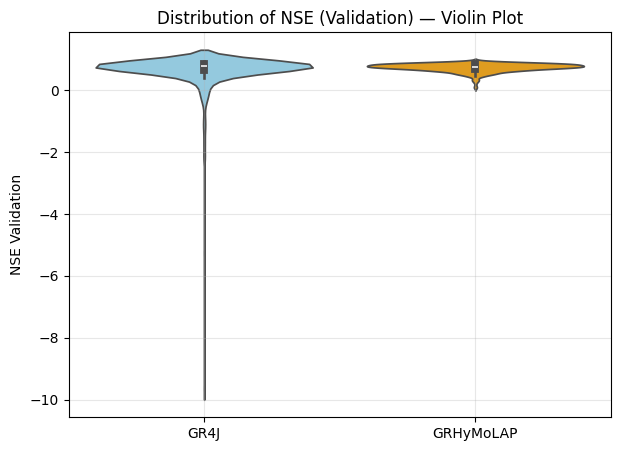

In [ ]:
plt.figure(figsize=(7,5))
sns.violinplot(data=[nse_val_gr4j, nse_val_grhymolap], palette=['skyblue','orange'])
plt.xticks([0,1], ['GR4J','GRHyMoLAP'])
plt.ylabel('NSE Validation')
plt.title('Distribution of NSE (Validation) — Violin Plot')
plt.grid(alpha=0.3)
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

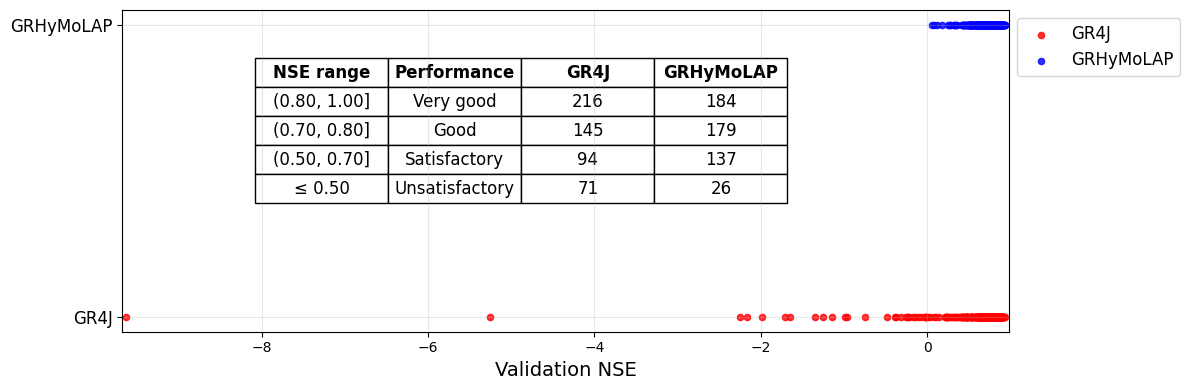

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Model data
# ----------------------------
models = {
    "GR4J": nse_val_gr4j,
    "GRHyMoLAP": nse_val_grhymolap
}

# ----------------------------
# NSE classes with intervals
# ----------------------------
nse_classes = [
    (0.8, 1.0, "Very good"),
    (0.7, 0.8, "Good"),
    (0.5, 0.7, "Satisfactory"),
    (-np.inf, 0.5, "Unsatisfactory")
]

# ----------------------------
# Prepare table with intervals and number of basins
# ----------------------------
table_data = []
for low, high, label in nse_classes:
    if low > -np.inf:
        interval = f"({low:.2f}, {high:.2f}]"
    else:
        interval = f"≤ {high:.2f}"  # <- last interval keeps <=
    row = [interval, label]  # Interval first, then Class
    for model_name, values in models.items():
        count = sum((np.array(values) > low) & (np.array(values) <= high))
        row.append(str(count))
    table_data.append(row)

# ----------------------------
# Dotplot
# ----------------------------
plt.figure(figsize=(12,4))
plt.scatter(models["GR4J"], np.ones_like(models["GR4J"])*1, color='red', alpha=0.8, s=20, label='GR4J')
plt.scatter(models["GRHyMoLAP"], np.ones_like(models["GRHyMoLAP"])*2, color='blue', alpha=0.8, s=20, label='GRHyMoLAP')

plt.yticks([1,2], ['GR4J','GRHyMoLAP'], fontsize=12)
plt.xlabel('Validation NSE', fontsize=14)
plt.grid(alpha=0.3)
plt.xlim(min(min(models["GR4J"]), min(models["GRHyMoLAP"])) - 0.05,
         max(max(models["GR4J"]), max(models["GRHyMoLAP"])) + 0.05)

plt.legend(loc='upper left', bbox_to_anchor=(1,1), fontsize=12, title_fontsize=13)

# ----------------------------
# Add table with Interval first
# ----------------------------
col_labels = ["NSE range", "Performance", "GR4J", "GRHyMoLAP"]

table = plt.table(cellText=table_data,
                  colLabels=col_labels,
                  cellLoc='center',
                  colLoc='center',
                  loc='center',
                  bbox=[0.15, 0.4, 0.6, 0.45])

# Make headers bold
for j, label in enumerate(col_labels):
    cell = table[0, j]  # first row, column j
    cell.set_text_props(fontweight='bold')

# Enable all borders
for (i,j), cell in table.get_celld().items():
    cell.set_linewidth(1.0)

table.auto_set_font_size(False)
table.set_fontsize(12)

plt.tight_layout()
plt.savefig("NSE.jpeg", format='jpeg', dpi=700)
#files.download("NSE.jpeg")
plt.show()